<a href="https://colab.research.google.com/github/dg2610122/Daegun26Veritas/blob/main/10122_%EC%9D%B4%EA%B7%9C%EB%AF%BC_1%ED%95%99%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

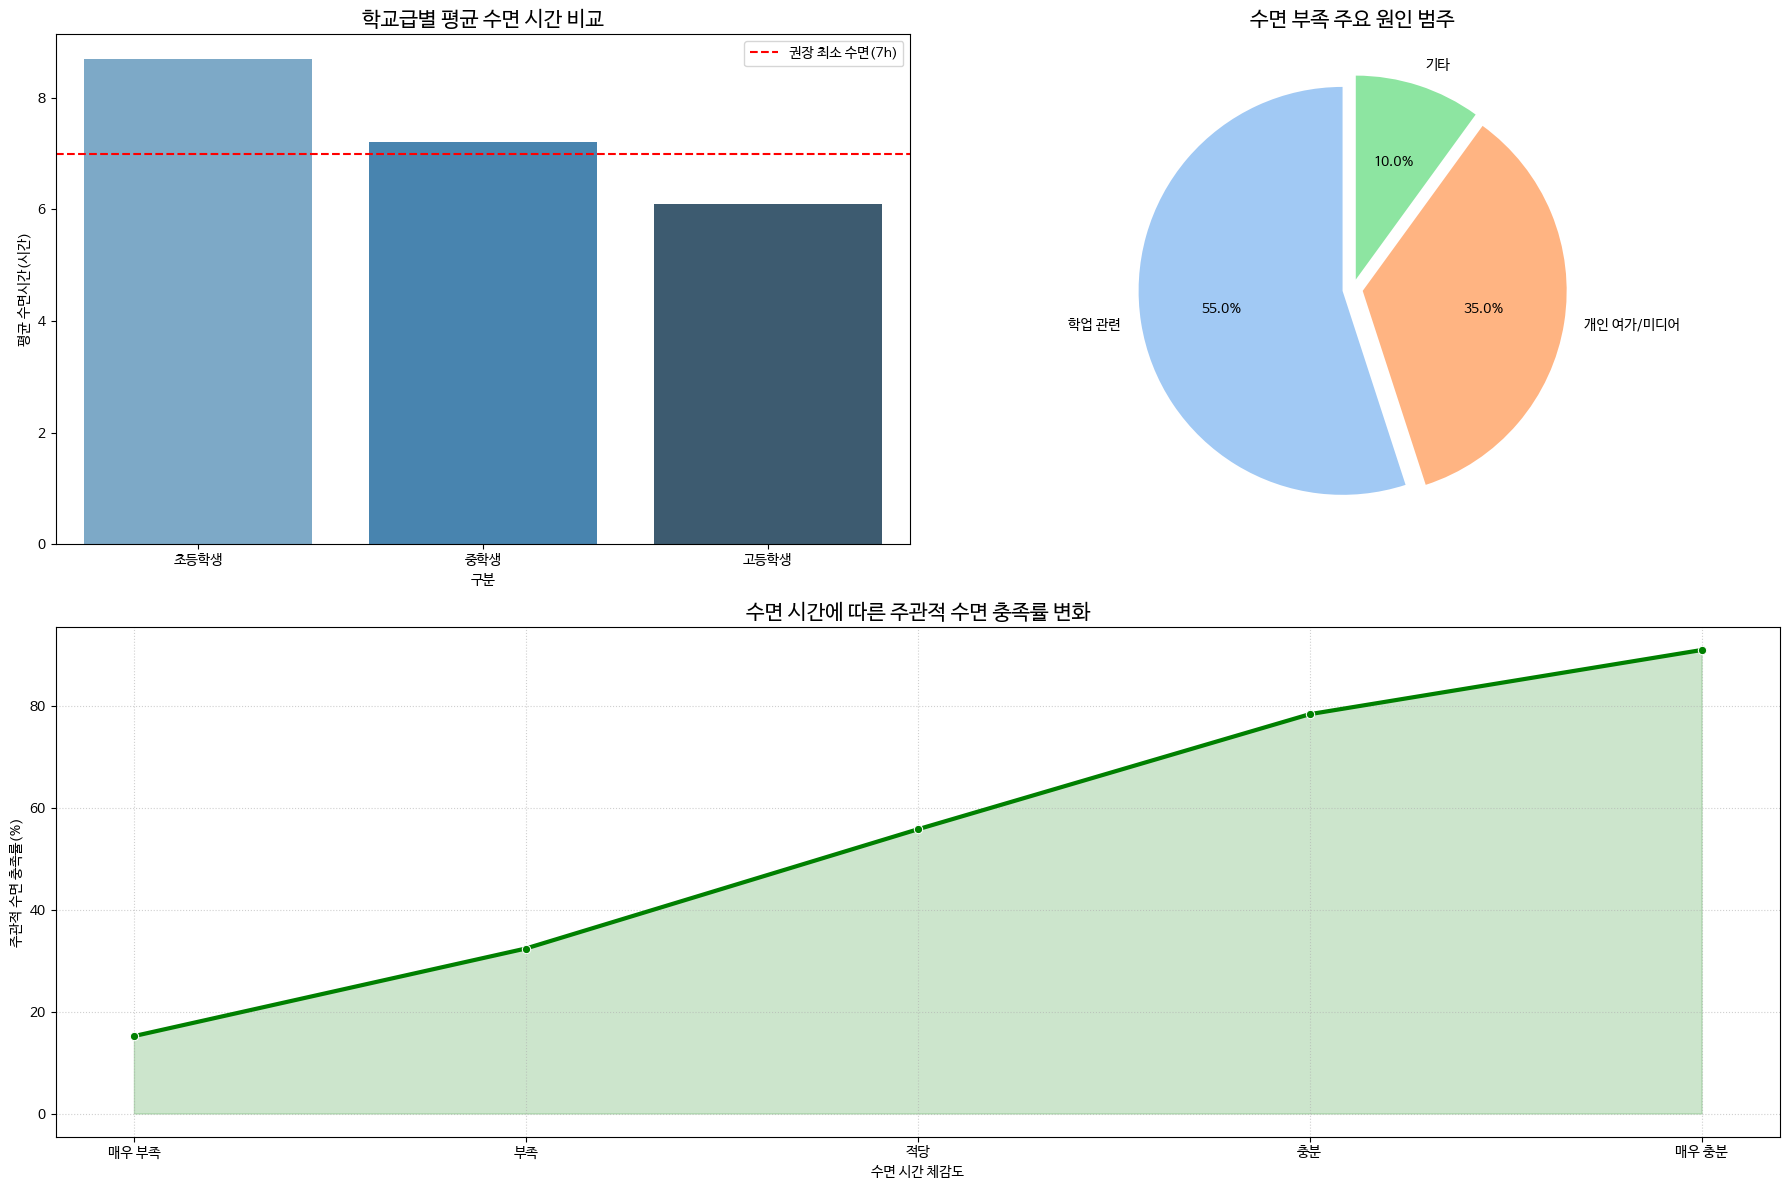

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 1. 한글 폰트 설치 및 등록
!apt-get install -qq -y fonts-nanum > /dev/null

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
# 폰트 매니저에 명시적으로 추가
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 구성
school_sleep_data = {'구분': ['초등학생', '중학생', '고등학생'], '평균 수면시간(시간)': [8.7, 7.2, 6.1]}
df_school = pd.DataFrame(school_sleep_data)

reasons_data = {
    '대분류': ['학업 관련', '개인 여가/미디어', '기타'],
    '비중(%)': [55, 35, 10]
}
df_reasons = pd.DataFrame(reasons_data)

satisfaction_data = {
    '수면시간': ['매우 부족', '부족', '적당', '충분', '매우 충분'],
    '주관적 수면 충족률(%)': [15.2, 32.4, 55.8, 78.4, 91.0]
}
df_sat = pd.DataFrame(satisfaction_data)

# 3. 시각화
fig = plt.figure(figsize=(18, 12))

# 그래프 1: 학교급별 수면 시간
ax1 = plt.subplot(2, 2, 1)
sns.barplot(x='구분', y='평균 수면시간(시간)', data=df_school, hue='구분', palette='Blues_d', legend=False)
ax1.set_title('학교급별 평균 수면 시간 비교', fontproperties=font_prop, fontsize=15)
ax1.set_xlabel('구분', fontproperties=font_prop)
ax1.set_ylabel('평균 수면시간(시간)', fontproperties=font_prop)
for t in ax1.get_xticklabels():
    t.set_fontproperties(font_prop)
ax1.axhline(7, color='red', linestyle='--', label='권장 최소 수면(7h)')
ax1.legend(prop=font_prop)

# 그래프 2: 수면 부족 주요 원인
plt.subplot(2, 2, 2)
patches, texts, autotexts = plt.pie(df_reasons['비중(%)'], labels=df_reasons['대분류'], autopct='%1.1f%%',
                                    colors=sns.color_palette('pastel'), startangle=90, explode=[0.05, 0.05, 0.05])
plt.title('수면 부족 주요 원인 범주', fontproperties=font_prop, fontsize=15)
for text in texts:
    text.set_fontproperties(font_prop)

# 그래프 3: 수면 시간과 충족률의 관계
ax3 = plt.subplot(2, 1, 2)
sns.lineplot(x='수면시간', y='주관적 수면 충족률(%)', data=df_sat, marker='o', linewidth=3, color='green')
plt.fill_between(df_sat['수면시간'], df_sat['주관적 수면 충족률(%)'], alpha=0.2, color='green')
ax3.set_title('수면 시간에 따른 주관적 수면 충족률 변화', fontproperties=font_prop, fontsize=15)
ax3.set_xlabel('수면 시간 체감도', fontproperties=font_prop)
ax3.set_ylabel('주관적 수면 충족률(%)', fontproperties=font_prop)
for t in ax3.get_xticklabels():
    t.set_fontproperties(font_prop)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

```markdown
## 📊 데이터 분석 종합 결론 및 제언

### 1. 주요 분석 결과
*   **수면 부족의 심각성**: 학년이 올라갈수록 평균 수면 시간이 급격히 감소하며, 특히 고등학생은 권장 최소 수면 시간(7시간)에 크게 못 미치는 6.1시간을 기록하고 있습니다.
*   **원인의 편중**: 수면 부족 원인의 절반 이상(55%)이 학업 관련으로 나타나, 학생들의 수면권이 교육 환경에 의해 크게 제약받고 있음을 알 수 있습니다.
*   **만족도와의 상관관계**: 실제 수면 시간의 양적 부족은 주관적인 수면 충족률의 하락으로 직결되며, 이는 전반적인 삶의 만족도 저하로 이어질 가능성이 큽니다.

### 2. 정보 보완을 위한 제언 (Next Step)
데이터의 설득력을 높이기 위해 다음과 같은 추가 데이터 분석이 필요합니다:
1.  **성적과의 상관관계**: 수면 시간이 학업 성취도에 미치는 긍정적/부정적 영향 분석
2.  **정신 건강 지표**: 수면 시간과 우울감, 스트레스 지수 간의 관계
3.  **시계열 분석**: 지난 10년간 학생들의 수면 시간 변화 추이
```

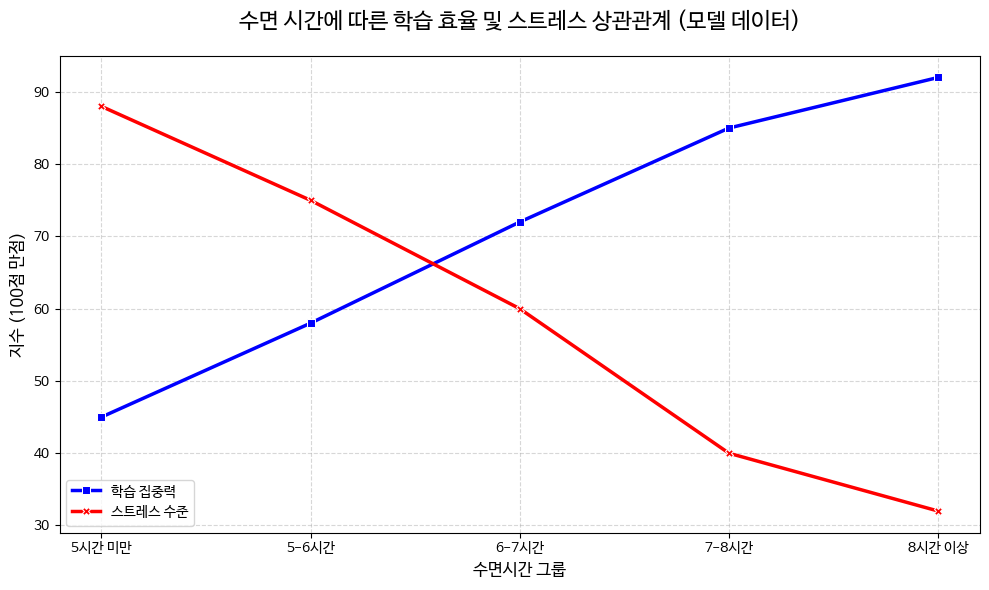

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# 1. 한글 폰트 설치 및 설정
if not os.path.exists('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'):
    !apt-get install -qq -y fonts-nanum > /dev/null

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 구성
impact_data = {
    '수면시간 그룹': ['5시간 미만', '5-6시간', '6-7시간', '7-8시간', '8시간 이상'],
    '집중력 점수(100점)': [45, 58, 72, 85, 92],
    '스트레스 지수(100점)': [88, 75, 60, 40, 32]
}
df_impact = pd.DataFrame(impact_data)

# 3. 시각화 개선
plt.figure(figsize=(10, 6))
sns.lineplot(x='수면시간 그룹', y='집중력 점수(100점)', data=df_impact, marker='s', label='학습 집중력', color='blue', linewidth=2.5)
sns.lineplot(x='수면시간 그룹', y='스트레스 지수(100점)', data=df_impact, marker='X', label='스트레스 수준', color='red', linewidth=2.5)

plt.title('수면 시간에 따른 학습 효율 및 스트레스 상관관계 (모델 데이터)', fontproperties=font_prop, fontsize=16, pad=20)
plt.xlabel('수면시간 그룹', fontproperties=font_prop, fontsize=12)
plt.ylabel('지수 (100점 만점)', fontproperties=font_prop, fontsize=12)

for t in plt.gca().get_xticklabels():
    t.set_fontproperties(font_prop)

plt.legend(prop=font_prop)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

NameError: name 'df_school' is not defined

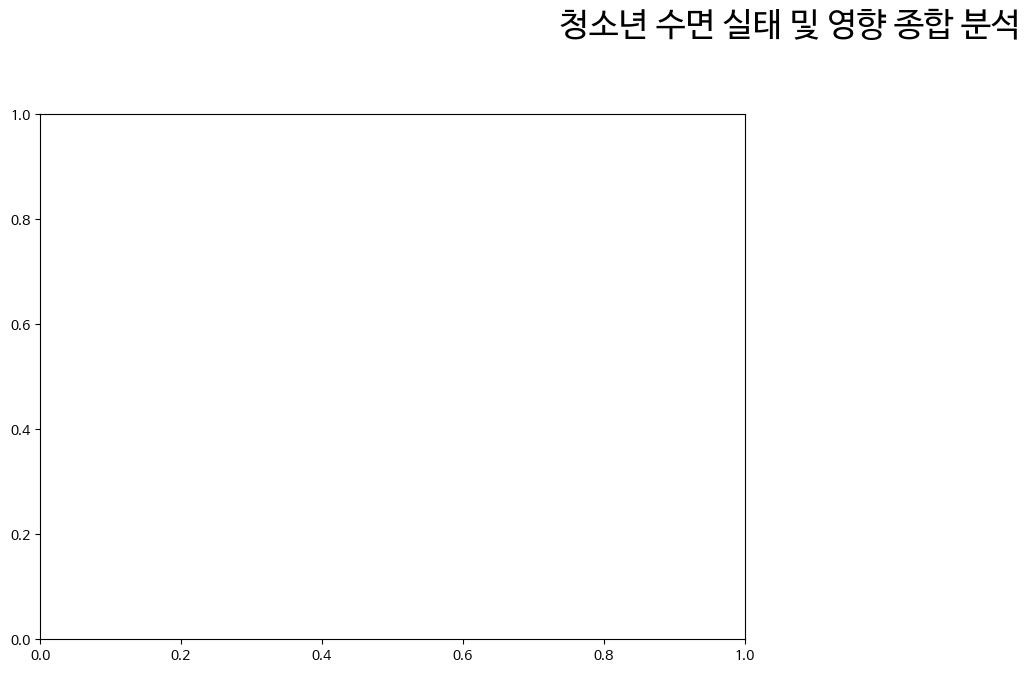

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'NanumBarunGothic'
fig = plt.figure(figsize=(20, 15))
plt.suptitle('청소년 수면 실태 및 영향 종합 분석', fontproperties=font_prop, fontsize=24, y=0.95)

# 1. 학교급별 수면 시간 (Bar Chart)
ax1 = plt.subplot(2, 2, 1)
sns.barplot(x='구분', y='평균 수면시간(시간)', data=df_school, hue='구분', palette='Blues_d', ax=ax1, legend=False)
ax1.set_title('① 학교급별 평균 수면 시간', fontproperties=font_prop, fontsize=16)
ax1.axhline(7, color='red', linestyle='--', label='권장 최소(7h)')
ax1.legend(prop=font_prop)

# 2. 수면 부족 원인 (Pie Chart)
ax2 = plt.subplot(2, 2, 2)
ax2.pie(df_reasons['비중(%)'], labels=df_reasons['대분류'], autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
ax2.set_title('② 수면 부족의 주요 원인', fontproperties=font_prop, fontsize=16)
for text in ax2.texts:
    text.set_fontproperties(font_prop)

# 3. 수면 시간에 따른 상관관계 모델 (Line Chart)
ax3 = plt.subplot(2, 1, 2)
sns.lineplot(x='수면시간 그룹', y='집중력 점수(100점)', data=df_impact, marker='s', label='학습 집중력', color='blue', linewidth=3, ax=ax3)
sns.lineplot(x='수면시간 그룹', y='스트레스 지수(100점)', data=df_impact, marker='X', label='스트레스 수준', color='red', linewidth=3, ax=ax3)
ax3.set_title('③ 수면량과 학습 효율 및 스트레스의 상관관계 (종합)', fontproperties=font_prop, fontsize=16)
ax3.set_ylabel('지수 (Score)', fontproperties=font_prop)
ax3.legend(prop=font_prop)
ax3.grid(True, alpha=0.3)

# 한글 폰트 적용 레이블 설정
for ax in [ax1, ax3]:
    for t in ax.get_xticklabels():
        t.set_fontproperties(font_prop)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

```markdown
# 📊 청소년 수면 실태 종합 대시보드
이 대시보드는 한국청소년정책연구원의 객관적 실태 조사 자료와 그에 따른 학습/심리 영향 모델을 통합하여 보여줍니다.
```

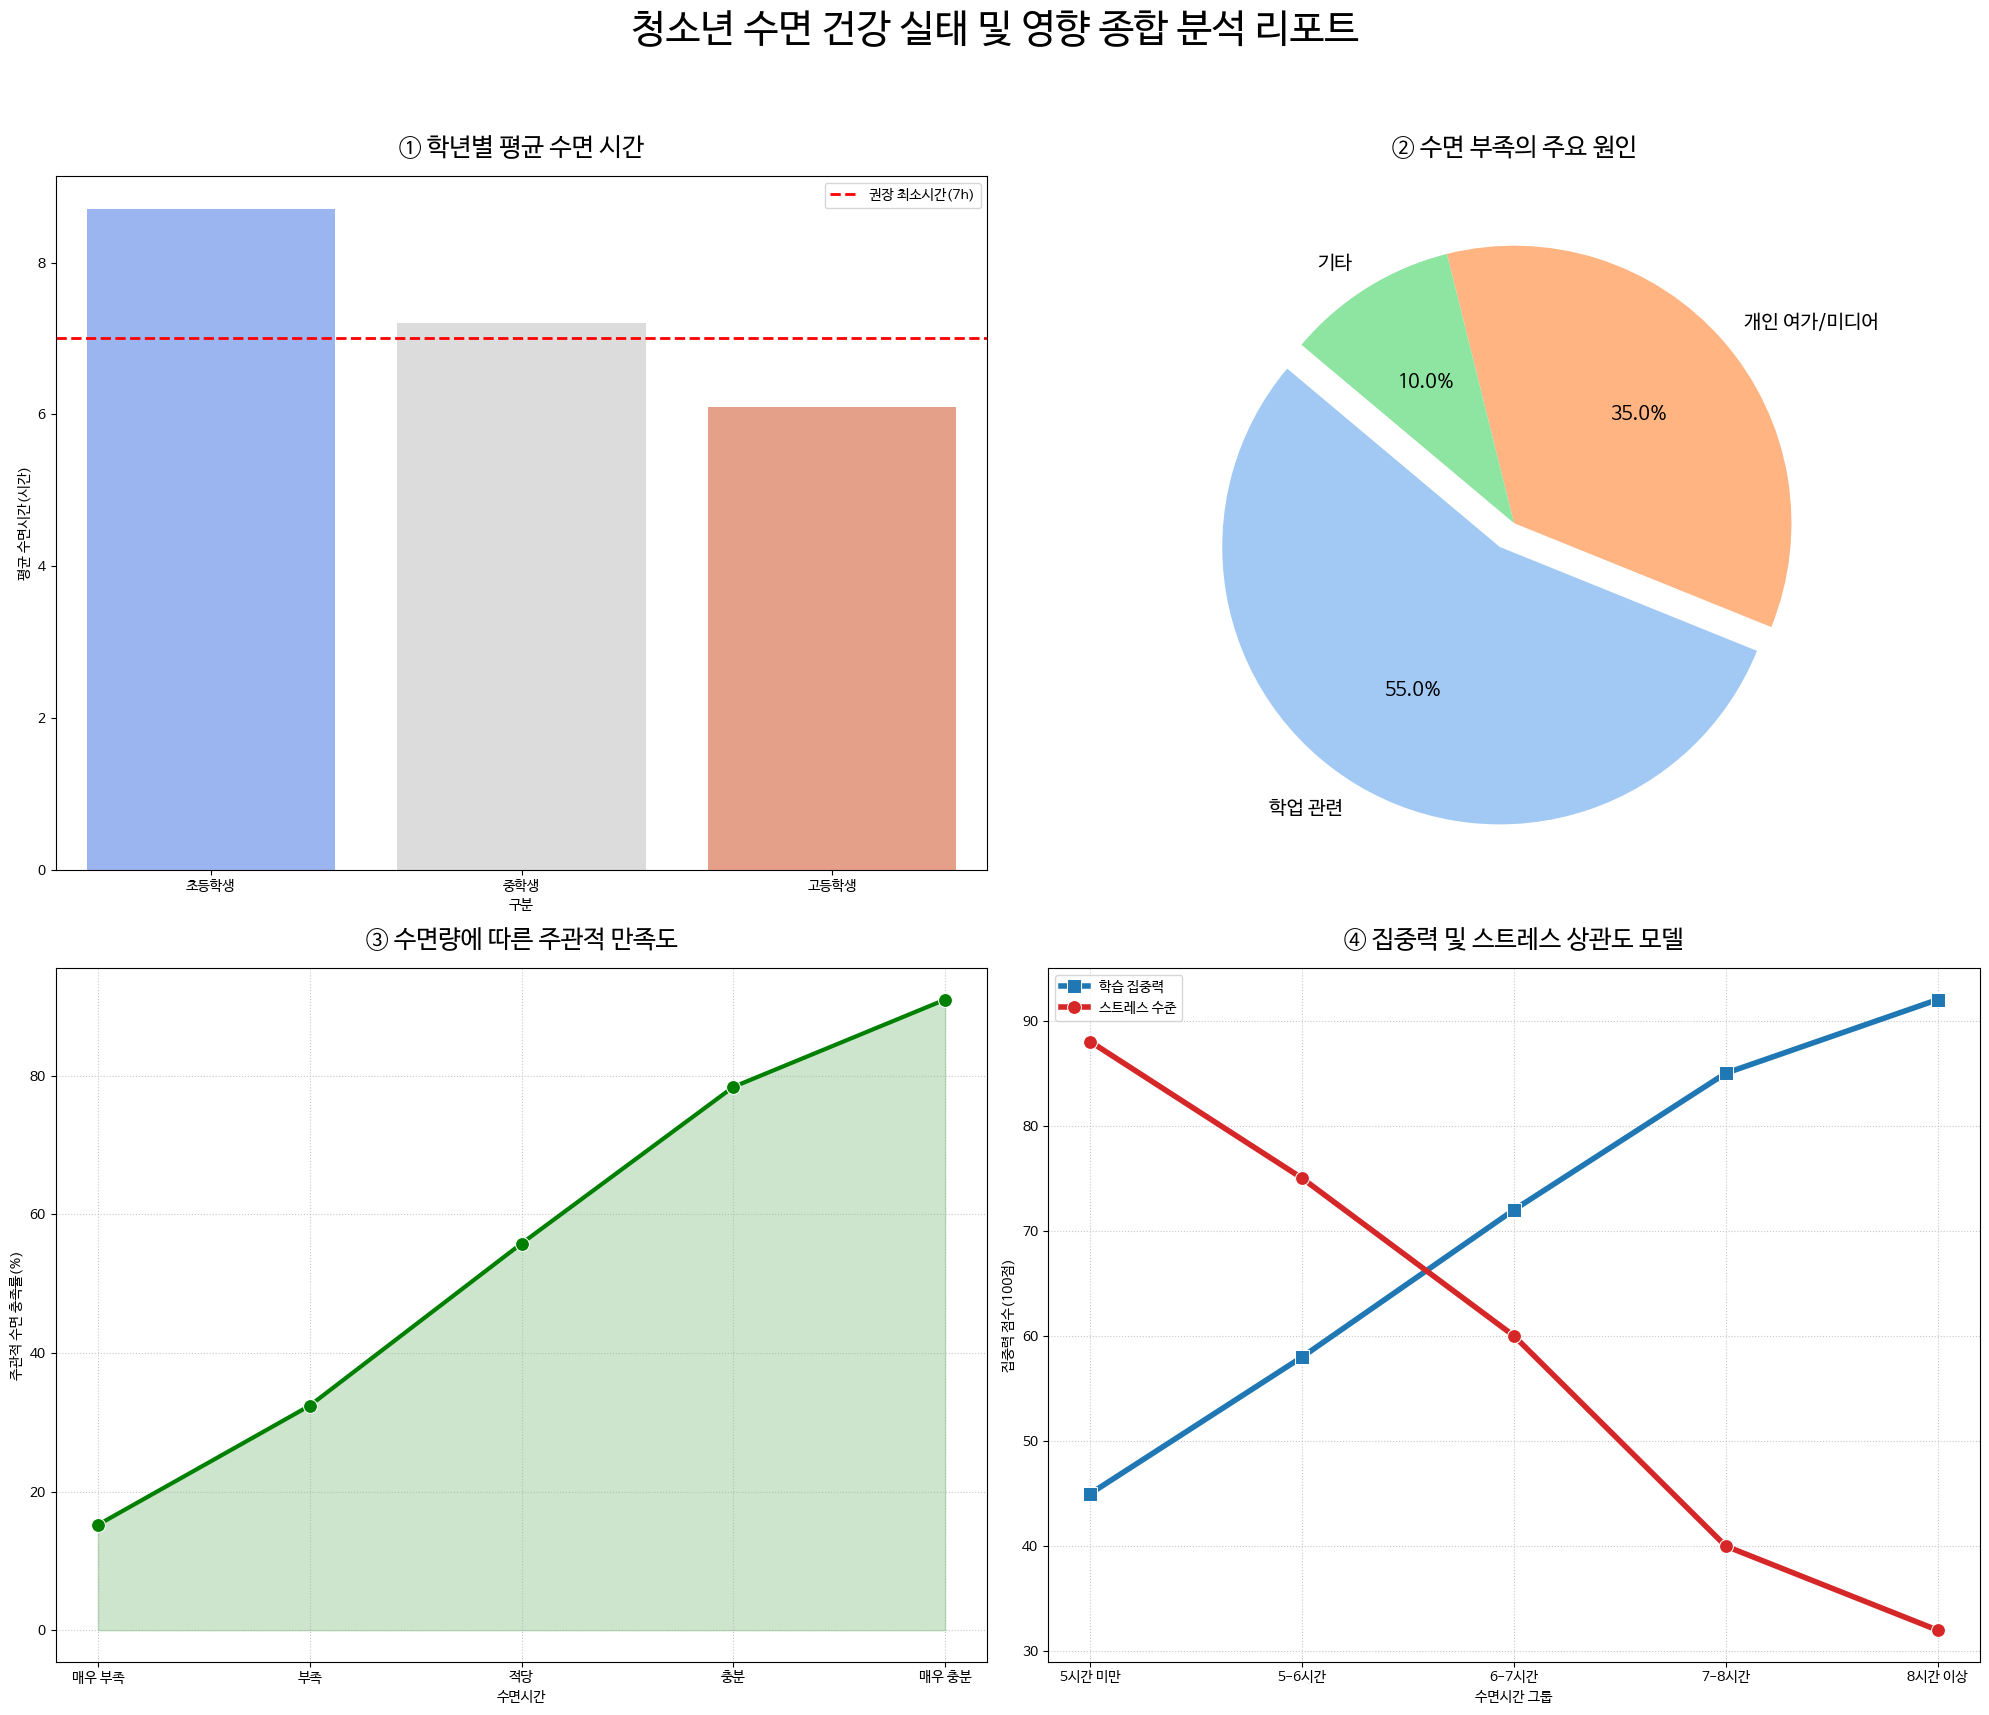

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# 1. 환경 설정 및 한글 폰트 로드
if not os.path.exists('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'):
    !apt-get install -qq -y fonts-nanum > /dev/null

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 통합 대시보드를 위한 모든 데이터 재정의 (Self-contained)
df_school = pd.DataFrame({'구분': ['초등학생', '중학생', '고등학생'], '평균 수면시간(시간)': [8.7, 7.2, 6.1]})
df_reasons = pd.DataFrame({'대분류': ['학업 관련', '개인 여가/미디어', '기타'], '비중(%)': [55, 35, 10]})
df_sat = pd.DataFrame({'수면시간': ['매우 부족', '부족', '적당', '충분', '매우 충분'], '주관적 수면 충족률(%)': [15.2, 32.4, 55.8, 78.4, 91.0]})
df_impact = pd.DataFrame({
    '수면시간 그룹': ['5시간 미만', '5-6시간', '6-7시간', '7-8시간', '8시간 이상'],
    '집중력 점수(100점)': [45, 58, 72, 85, 92],
    '스트레스 지수(100점)': [88, 75, 60, 40, 32]
})

# 3. 통합 대시보드 시각화 (4-Panel Layout)
fig = plt.figure(figsize=(20, 18))
plt.suptitle('청소년 수면 건강 실태 및 영향 종합 분석 리포트', fontproperties=font_prop, fontsize=28, y=0.98)

# [Graph 1] 학년별 수면 시간 현황
ax1 = plt.subplot(2, 2, 1)
sns.barplot(x='구분', y='평균 수면시간(시간)', data=df_school, hue='구분', palette='coolwarm', ax=ax1, legend=False)
ax1.set_title('① 학년별 평균 수면 시간', fontproperties=font_prop, fontsize=18, pad=15)
ax1.axhline(7, color='red', linestyle='--', linewidth=2, label='권장 최소시간(7h)')
ax1.legend(prop=font_prop)

# [Graph 2] 수면 부족 원인 비중
ax2 = plt.subplot(2, 2, 2)
ax2.pie(df_reasons['비중(%)'], labels=df_reasons['대분류'], autopct='%1.1f%%', startangle=140, explode=[0.1, 0, 0], colors=sns.color_palette('pastel'), textprops={'fontproperties': font_prop, 'fontsize': 14})
ax2.set_title('② 수면 부족의 주요 원인', fontproperties=font_prop, fontsize=18, pad=15)

# [Graph 3] 수면 충족률 변화 추이
ax3 = plt.subplot(2, 2, 3)
sns.lineplot(x='수면시간', y='주관적 수면 충족률(%)', data=df_sat, marker='o', markersize=10, linewidth=3, color='green', ax=ax3)
ax3.fill_between(df_sat['수면시간'], df_sat['주관적 수면 충족률(%)'], alpha=0.2, color='green')
ax3.set_title('③ 수면량에 따른 주관적 만족도', fontproperties=font_prop, fontsize=18, pad=15)
ax3.grid(True, linestyle=':', alpha=0.7)

# [Graph 4] 학습 효율 및 스트레스 상관관계
ax4 = plt.subplot(2, 2, 4)
sns.lineplot(x='수면시간 그룹', y='집중력 점수(100점)', data=df_impact, marker='s', markersize=10, label='학습 집중력', color='#1f77b4', linewidth=4, ax=ax4)
sns.lineplot(x='수면시간 그룹', y='스트레스 지수(100점)', data=df_impact, marker='o', markersize=10, label='스트레스 수준', color='#d62728', linewidth=4, ax=ax4)
ax4.set_title('④ 집중력 및 스트레스 상관도 모델', fontproperties=font_prop, fontsize=18, pad=15)
ax4.legend(prop=font_prop)
ax4.grid(True, linestyle=':', alpha=0.7)

# 모든 축 레이블 폰트 일괄 적용
for ax in [ax1, ax3, ax4]:
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontproperties(font_prop)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()